In [17]:
from common import *
import serial, csv, time
from datetime import datetime

In [18]:
def read_pipe_to_csv(arduino_port, stop_after=0, 
                     stop_below_temperature=30, uncertainty=9/4, 
                     debug_print=True):
    """
    Read data from Arduino over serial, write to CSV, and stop based on number of points
    or a minimum temperature threshold.
    
    Args:
        pipe_title (str): Title used in filename.
        arduino_port (str): Serial port, e.g., '/dev/ttyACM0'.
        stop_after (int): Number of datapoints to collect; 0 = unlimited.
        stop_below_temperature (float): Stop if temperature drops below this (in K).
        uncertainty (float): Measurement uncertainty to include in CSV.
        debug_print (bool): Print each line as it's collected.
    """
    # timestamped filename
    now = datetime.now()
    timestamp_str = now.strftime("%Y%m%d_%H%M%S")
    csv_filename = f"./data/test_{timestamp_str}.csv"
    
    print(f"Saving data to: {csv_filename}")
    
    # open serial port
    ser = serial.Serial(arduino_port, 9600, timeout=1)
    time.sleep(2)  # allow Arduino to reset

    # First datapoint is defined as t = 0 seconds
    seconds = 0
    
    try:
        with open(csv_filename, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Temperature 1 (K)', 'Temperature 2 (K)', 'Temperature 3 (K)', 'Uncertainty (K)', 'Time (s)'])
            
            while True:
                # stop based on number of points/seconds
                if stop_after > 0 and seconds >= stop_after:
                    print(f"Reached {stop_after} datapoints/seconds. Stopping.")
                    break
                
                # read line
                line_raw = ser.readline().decode('utf-8').strip()
                if not line_raw:
                    continue
                
                try:
                    temps = np.array([float(token) for token in line_raw.split(",")])
                    
                    # stop based on temperature
                    if np.all(temps < stop_below_temperature) and debug_print:
                        print(f"All temperatures are below {stop_below_temperature:.2f} C. Stopping.")
                        break

                    if debug_print:
                        if stop_after > 0:
                            print(f'{seconds}/{stop_after}', end=' ')
                        print(temps[0], 'C,', temps[1], 'C,', temps[2], 'C')

                    # save to CSV
                    temps = temps + 273.15 
                    writer.writerow([temps[0], temps[1], temps[2], uncertainty, seconds])
                    f.flush()
                    
                    seconds += 1
                    
                except ValueError:
                    continue
                    
    except KeyboardInterrupt:
        print("Stopped by user.")
        
    finally:
        ser.close()
        print("Serial port closed.")

From the MAX6675 K-Type Thermocouple Data Sheet, the uncertainty in the thermocouple at 5 volt VCC measurement between $0^\circ$ C and $+700^\circ $ C is $\pm 9/4 = \pm 2.25$ C/K [[1]](https://www.analog.com/media/en/technical-documentation/data-sheets/max6675.pdf).

In [20]:
read_pipe_to_csv('/dev/ttyACM0')

Saving data to: ./data/test_20260114_154138.csv
51.0 C, 52.25 C, 63.5 C
50.75 C, 52.5 C, 62.75 C
52.0 C, 53.0 C, 63.75 C
52.25 C, 53.75 C, 64.0 C
53.0 C, 53.75 C, 64.5 C
53.25 C, 54.5 C, 64.75 C
54.25 C, 55.0 C, 64.25 C
54.75 C, 55.5 C, 65.0 C
55.25 C, 55.75 C, 65.75 C
56.0 C, 56.0 C, 66.0 C
56.25 C, 56.75 C, 66.5 C
57.0 C, 56.5 C, 66.5 C
57.5 C, 56.75 C, 66.5 C
57.75 C, 57.5 C, 67.75 C
58.75 C, 58.0 C, 68.0 C
59.0 C, 58.25 C, 68.25 C
59.0 C, 58.0 C, 68.5 C
59.75 C, 58.75 C, 69.0 C
59.75 C, 59.25 C, 69.25 C
60.75 C, 59.5 C, 69.75 C
60.75 C, 60.0 C, 70.0 C
62.25 C, 60.5 C, 69.5 C
62.75 C, 60.5 C, 70.25 C
63.5 C, 60.5 C, 70.75 C
63.5 C, 61.0 C, 70.0 C
64.0 C, 61.25 C, 70.75 C
64.5 C, 62.25 C, 71.0 C
64.75 C, 62.5 C, 71.75 C
65.25 C, 62.75 C, 72.0 C
64.75 C, 63.0 C, 72.5 C
65.5 C, 63.25 C, 72.5 C
65.5 C, 63.5 C, 72.0 C
66.5 C, 63.25 C, 73.25 C
66.75 C, 64.25 C, 72.75 C
66.0 C, 64.5 C, 73.25 C
67.5 C, 64.75 C, 73.25 C
67.5 C, 65.25 C, 73.75 C
67.75 C, 65.25 C, 74.25 C
68.0 C, 65.5 C, 74.0 

66.0 C, 70.75 C, 77.25 C
65.75 C, 70.5 C, 77.5 C
65.5 C, 70.75 C, 77.75 C
65.0 C, 70.5 C, 77.25 C
66.5 C, 71.75 C, 77.25 C
67.0 C, 71.5 C, 77.75 C
67.5 C, 71.0 C, 77.25 C
67.5 C, 71.25 C, 77.25 C
65.75 C, 70.0 C, 77.0 C
66.0 C, 70.75 C, 77.25 C
67.0 C, 70.75 C, 77.25 C
67.75 C, 70.25 C, 77.75 C
67.5 C, 70.75 C, 77.5 C
67.5 C, 70.75 C, 77.5 C
67.0 C, 70.0 C, 76.75 C
67.25 C, 70.75 C, 77.75 C
67.5 C, 70.25 C, 77.0 C
67.5 C, 70.0 C, 77.25 C
67.5 C, 70.5 C, 77.0 C
67.5 C, 70.5 C, 77.25 C
67.0 C, 70.75 C, 77.75 C
67.0 C, 70.5 C, 77.25 C
67.25 C, 70.75 C, 77.25 C
67.25 C, 70.75 C, 77.25 C
67.25 C, 71.0 C, 76.75 C
67.25 C, 70.75 C, 77.0 C
67.25 C, 71.0 C, 77.0 C
67.0 C, 71.0 C, 77.25 C
67.25 C, 70.75 C, 77.25 C
67.0 C, 70.25 C, 76.75 C
66.75 C, 70.5 C, 76.5 C
67.0 C, 70.25 C, 77.25 C
67.25 C, 70.5 C, 76.75 C
67.25 C, 70.5 C, 77.25 C
67.25 C, 70.75 C, 77.25 C
67.25 C, 70.75 C, 77.0 C
67.0 C, 70.0 C, 76.75 C
66.75 C, 70.75 C, 77.25 C
67.0 C, 70.25 C, 76.75 C
67.0 C, 70.5 C, 76.5 C
67.0 C, 70.5 

51.5 C, 62.25 C, 68.25 C
51.25 C, 62.0 C, 68.0 C
51.0 C, 61.75 C, 68.0 C
51.5 C, 62.25 C, 67.75 C
51.5 C, 62.0 C, 68.0 C
51.75 C, 62.25 C, 68.25 C
51.25 C, 62.25 C, 68.25 C
52.0 C, 62.25 C, 68.0 C
51.0 C, 62.0 C, 68.0 C
51.25 C, 62.25 C, 67.75 C
51.25 C, 61.5 C, 67.75 C
51.25 C, 61.5 C, 68.0 C
51.25 C, 62.25 C, 67.75 C
50.5 C, 62.0 C, 67.75 C
50.75 C, 61.75 C, 68.25 C
50.75 C, 62.0 C, 68.25 C
50.75 C, 62.0 C, 68.0 C
51.25 C, 62.0 C, 67.75 C
51.0 C, 61.5 C, 67.75 C
51.0 C, 61.75 C, 68.0 C
52.0 C, 62.5 C, 67.5 C
51.0 C, 61.5 C, 67.5 C
50.5 C, 61.5 C, 67.5 C
50.75 C, 62.0 C, 67.5 C
50.75 C, 61.75 C, 67.75 C
51.5 C, 61.25 C, 67.75 C
52.0 C, 62.0 C, 67.0 C
51.0 C, 61.5 C, 67.75 C
50.75 C, 61.5 C, 67.75 C
51.0 C, 62.0 C, 67.5 C
50.5 C, 61.75 C, 67.25 C
50.75 C, 61.5 C, 67.75 C
50.75 C, 61.75 C, 67.5 C
50.75 C, 61.75 C, 67.5 C
50.75 C, 61.5 C, 67.5 C
50.75 C, 62.0 C, 67.25 C
51.5 C, 62.0 C, 67.0 C
50.25 C, 61.5 C, 67.25 C
50.25 C, 61.25 C, 67.25 C
50.25 C, 61.5 C, 67.0 C
50.75 C, 61.75 C, 67.

43.25 C, 55.25 C, 59.0 C
43.75 C, 55.25 C, 59.5 C
43.5 C, 54.75 C, 59.5 C
43.25 C, 55.5 C, 59.5 C
43.5 C, 55.5 C, 59.5 C
43.0 C, 55.5 C, 59.5 C
43.5 C, 55.25 C, 59.5 C
43.5 C, 55.25 C, 59.0 C
44.25 C, 54.75 C, 59.25 C
45.0 C, 55.75 C, 59.5 C
44.5 C, 55.0 C, 59.75 C
43.25 C, 55.25 C, 59.5 C
43.25 C, 55.25 C, 59.0 C
43.25 C, 55.25 C, 59.5 C
43.25 C, 54.75 C, 59.5 C
43.25 C, 55.0 C, 59.5 C
43.25 C, 55.25 C, 58.5 C
43.25 C, 55.25 C, 59.5 C
42.75 C, 54.75 C, 59.0 C
43.0 C, 55.25 C, 58.75 C
43.0 C, 55.25 C, 58.75 C
43.0 C, 54.75 C, 59.25 C
45.25 C, 54.25 C, 59.5 C
45.0 C, 54.75 C, 59.0 C
44.25 C, 55.0 C, 59.5 C
42.75 C, 54.75 C, 59.0 C
43.0 C, 54.75 C, 59.0 C
43.0 C, 55.0 C, 58.5 C
44.0 C, 54.75 C, 59.25 C
44.25 C, 55.0 C, 59.25 C
43.5 C, 54.5 C, 59.5 C
43.75 C, 54.75 C, 59.0 C
42.75 C, 54.75 C, 59.25 C
43.25 C, 54.5 C, 59.0 C
43.75 C, 54.25 C, 59.25 C
44.0 C, 54.75 C, 59.0 C
44.0 C, 55.0 C, 58.75 C
43.5 C, 54.75 C, 59.0 C
43.5 C, 54.5 C, 59.25 C
44.25 C, 54.75 C, 59.25 C
44.25 C, 54.25 C, 5

37.25 C, 49.0 C, 52.5 C
37.25 C, 49.0 C, 52.75 C
37.0 C, 48.75 C, 53.0 C
37.5 C, 49.25 C, 53.0 C
37.75 C, 48.75 C, 53.0 C
37.25 C, 49.25 C, 52.75 C
36.75 C, 49.25 C, 53.0 C
37.25 C, 48.75 C, 52.5 C
37.25 C, 48.25 C, 52.75 C
37.0 C, 49.25 C, 52.75 C
37.25 C, 48.75 C, 52.25 C
37.25 C, 48.75 C, 53.0 C
36.75 C, 49.0 C, 52.5 C
37.0 C, 49.25 C, 52.5 C
37.25 C, 49.25 C, 52.75 C
36.75 C, 49.25 C, 52.75 C
37.0 C, 48.5 C, 52.5 C
36.5 C, 49.0 C, 52.5 C
36.5 C, 49.25 C, 52.75 C
36.5 C, 49.0 C, 52.75 C
37.0 C, 48.75 C, 52.75 C
36.75 C, 48.5 C, 52.5 C
37.0 C, 49.0 C, 52.5 C
37.0 C, 49.0 C, 52.5 C
36.5 C, 48.5 C, 52.5 C
36.5 C, 49.0 C, 52.5 C
36.75 C, 48.75 C, 52.25 C
36.0 C, 48.75 C, 52.25 C
36.75 C, 49.0 C, 52.0 C
36.75 C, 48.75 C, 52.75 C
36.5 C, 48.25 C, 52.5 C
36.75 C, 48.5 C, 52.0 C
36.5 C, 48.25 C, 52.0 C
36.75 C, 48.75 C, 52.0 C
36.0 C, 48.5 C, 52.25 C
37.0 C, 48.75 C, 52.5 C
37.75 C, 48.25 C, 52.5 C
37.25 C, 48.0 C, 52.5 C
38.0 C, 48.75 C, 52.5 C
37.5 C, 48.5 C, 52.75 C
37.0 C, 47.75 C, 52.5

...

27.75 C, 36.5 C, 40.0 C
27.5 C, 36.5 C, 39.75 C
27.0 C, 36.5 C, 39.75 C
27.0 C, 36.25 C, 39.25 C
26.75 C, 36.5 C, 39.75 C
26.5 C, 36.75 C, 39.25 C
27.0 C, 36.25 C, 39.75 C
27.25 C, 36.75 C, 39.75 C
26.5 C, 36.5 C, 39.5 C
27.0 C, 36.75 C, 39.5 C
27.25 C, 36.5 C, 39.5 C
27.25 C, 36.25 C, 39.5 C
27.0 C, 36.75 C, 39.5 C
26.75 C, 35.75 C, 39.75 C
26.5 C, 36.75 C, 39.5 C
26.75 C, 36.25 C, 39.25 C
27.25 C, 36.5 C, 39.5 C
26.25 C, 36.25 C, 39.5 C
26.75 C, 36.0 C, 39.5 C
27.0 C, 36.75 C, 39.25 C
26.75 C, 36.5 C, 39.25 C
26.75 C, 36.25 C, 39.25 C
27.0 C, 36.75 C, 39.0 C
26.25 C, 36.25 C, 39.25 C
27.0 C, 36.0 C, 39.0 C
26.5 C, 36.0 C, 39.75 C
26.75 C, 36.0 C, 39.0 C
26.75 C, 36.5 C, 39.25 C
26.25 C, 36.5 C, 39.25 C
27.0 C, 36.5 C, 39.25 C
26.75 C, 36.5 C, 39.25 C
27.0 C, 36.0 C, 38.75 C
26.75 C, 36.0 C, 39.25 C
26.75 C, 36.5 C, 39.0 C
26.5 C, 36.5 C, 39.25 C
27.0 C, 36.0 C, 39.25 C
26.75 C, 35.75 C, 39.5 C
27.0 C, 36.25 C, 39.25 C
26.75 C, 36.5 C, 39.25 C
26.75 C, 36.5 C, 39.25 C
26.5 C, 36.0 C, 

25.0 C, 34.0 C, 37.0 C
25.0 C, 34.25 C, 36.5 C
25.25 C, 34.5 C, 36.75 C
24.75 C, 34.25 C, 36.5 C
25.25 C, 34.25 C, 36.25 C
25.5 C, 34.25 C, 36.5 C
25.5 C, 34.25 C, 37.0 C
25.25 C, 34.25 C, 36.5 C
25.25 C, 34.25 C, 36.75 C
25.5 C, 34.25 C, 36.75 C
25.0 C, 34.5 C, 37.25 C
25.25 C, 34.25 C, 36.75 C
25.25 C, 34.25 C, 36.5 C
25.25 C, 34.25 C, 36.75 C
25.0 C, 34.25 C, 36.75 C
25.25 C, 33.75 C, 36.75 C
25.25 C, 34.25 C, 36.5 C
25.0 C, 34.25 C, 36.75 C
25.25 C, 34.25 C, 37.0 C
25.5 C, 34.0 C, 37.0 C
25.0 C, 34.0 C, 36.75 C
25.25 C, 34.25 C, 37.0 C
25.25 C, 34.25 C, 36.5 C
25.25 C, 34.0 C, 36.75 C
25.25 C, 34.0 C, 36.5 C
25.25 C, 33.75 C, 36.25 C
25.0 C, 34.0 C, 36.5 C
25.25 C, 34.25 C, 36.0 C
25.25 C, 34.25 C, 36.75 C
25.25 C, 34.0 C, 36.25 C
24.75 C, 34.25 C, 36.75 C
25.0 C, 33.75 C, 36.75 C
25.0 C, 34.0 C, 36.5 C
25.25 C, 33.75 C, 36.75 C
25.25 C, 34.0 C, 36.5 C
25.25 C, 33.75 C, 36.75 C
25.0 C, 34.0 C, 36.75 C
25.0 C, 34.0 C, 36.5 C
25.25 C, 33.75 C, 36.5 C
25.0 C, 34.0 C, 36.5 C
25.0 C, 34

24.0 C, 32.5 C, 34.5 C
23.5 C, 32.0 C, 34.25 C
24.0 C, 31.75 C, 34.5 C
23.75 C, 32.0 C, 34.5 C
24.0 C, 32.25 C, 34.5 C
23.5 C, 32.0 C, 34.5 C
23.5 C, 32.0 C, 34.5 C
24.0 C, 32.0 C, 34.5 C
23.5 C, 32.0 C, 35.0 C
23.75 C, 32.0 C, 34.25 C
23.75 C, 31.75 C, 34.5 C
24.0 C, 31.75 C, 34.5 C
23.75 C, 32.25 C, 34.5 C
23.5 C, 32.0 C, 34.5 C
24.0 C, 31.75 C, 34.0 C
24.0 C, 31.75 C, 34.5 C
23.5 C, 32.0 C, 34.5 C
23.5 C, 31.75 C, 34.25 C
23.5 C, 31.75 C, 34.5 C
23.5 C, 32.0 C, 34.0 C
24.0 C, 32.0 C, 34.5 C
24.0 C, 32.0 C, 34.75 C
23.5 C, 31.5 C, 34.5 C
23.5 C, 31.5 C, 34.5 C
23.75 C, 32.25 C, 34.5 C
24.0 C, 32.0 C, 34.0 C
23.75 C, 32.25 C, 34.5 C
24.0 C, 32.0 C, 34.25 C
24.0 C, 32.25 C, 34.5 C
23.75 C, 32.0 C, 34.0 C
23.5 C, 32.0 C, 34.5 C
24.0 C, 32.0 C, 34.5 C
23.75 C, 31.75 C, 34.25 C
24.0 C, 32.0 C, 34.25 C
24.0 C, 31.75 C, 34.5 C
23.75 C, 32.0 C, 34.0 C
24.25 C, 31.75 C, 34.5 C
24.0 C, 31.5 C, 34.25 C
23.25 C, 32.25 C, 34.0 C
24.0 C, 31.25 C, 34.5 C
24.75 C, 32.25 C, 34.5 C
24.25 C, 32.0 C, 35

23.0 C, 31.25 C, 32.75 C
24.0 C, 30.75 C, 33.0 C
24.25 C, 31.0 C, 33.0 C
25.0 C, 30.75 C, 33.0 C
24.5 C, 30.75 C, 33.0 C
24.0 C, 30.5 C, 33.0 C
24.25 C, 30.5 C, 32.5 C
24.0 C, 30.75 C, 32.75 C
24.0 C, 30.75 C, 32.25 C
23.25 C, 30.75 C, 33.0 C
23.5 C, 30.0 C, 32.75 C
24.0 C, 30.25 C, 32.75 C
24.5 C, 30.5 C, 32.75 C
24.0 C, 30.0 C, 32.25 C
23.75 C, 30.0 C, 32.5 C
24.75 C, 30.25 C, 32.75 C
24.0 C, 30.5 C, 32.75 C
24.5 C, 30.5 C, 32.5 C
24.5 C, 30.75 C, 32.75 C
24.0 C, 30.5 C, 33.0 C
22.75 C, 30.75 C, 32.75 C
22.75 C, 31.0 C, 32.5 C
22.75 C, 31.0 C, 32.75 C
22.75 C, 31.25 C, 32.75 C
22.5 C, 31.0 C, 32.25 C
22.25 C, 30.75 C, 32.75 C
22.5 C, 30.75 C, 33.0 C
23.0 C, 31.25 C, 32.75 C
22.75 C, 31.0 C, 32.75 C
23.0 C, 31.25 C, 32.75 C
23.25 C, 30.75 C, 32.75 C
23.25 C, 30.5 C, 32.75 C
23.0 C, 31.0 C, 32.75 C
22.5 C, 30.5 C, 32.75 C
22.5 C, 30.75 C, 32.5 C
23.0 C, 30.75 C, 32.5 C
23.0 C, 31.0 C, 32.75 C
23.0 C, 31.0 C, 32.75 C
23.0 C, 31.0 C, 32.75 C
23.25 C, 30.75 C, 32.5 C
22.75 C, 30.75 C, 32.

22.75 C, 29.5 C, 30.75 C
22.0 C, 29.5 C, 31.5 C
22.0 C, 29.25 C, 31.25 C
22.5 C, 29.5 C, 31.25 C
23.0 C, 29.5 C, 31.5 C
22.75 C, 29.5 C, 31.25 C
22.5 C, 29.25 C, 30.5 C
22.5 C, 29.5 C, 31.0 C
22.5 C, 29.75 C, 31.25 C
22.25 C, 29.75 C, 30.75 C
22.5 C, 29.25 C, 31.25 C
22.75 C, 29.75 C, 31.5 C
22.75 C, 29.75 C, 30.75 C
22.0 C, 29.25 C, 31.25 C
22.5 C, 29.5 C, 31.5 C
22.75 C, 29.25 C, 30.75 C
22.0 C, 29.25 C, 30.75 C
22.5 C, 29.5 C, 30.75 C
21.75 C, 29.5 C, 31.25 C
22.25 C, 29.5 C, 31.0 C
21.75 C, 29.25 C, 31.25 C
22.0 C, 29.0 C, 31.25 C
22.5 C, 30.0 C, 30.75 C
22.25 C, 29.5 C, 31.25 C
22.0 C, 29.25 C, 31.0 C
22.25 C, 29.5 C, 31.25 C
22.25 C, 29.5 C, 31.25 C
22.5 C, 29.0 C, 31.0 C
21.75 C, 29.0 C, 31.25 C
22.0 C, 29.0 C, 31.0 C
22.25 C, 29.25 C, 31.25 C
22.25 C, 29.5 C, 31.0 C
22.25 C, 28.75 C, 30.75 C
22.5 C, 29.25 C, 31.25 C
22.5 C, 29.25 C, 31.25 C
22.5 C, 29.0 C, 31.25 C
22.25 C, 29.25 C, 30.75 C
22.0 C, 29.5 C, 30.75 C
22.5 C, 29.25 C, 30.75 C
22.25 C, 28.5 C, 31.25 C
22.0 C, 29.5 C,

In [5]:
def load_max6675_csv_to_dataset(csv_filename):
    """
    Loads a CSV produced by the MAX6675 Arduino logger into a Dataset object
    using Python's built-in csv module.
    
    Args:
        csv_filename (str): Path to the CSV file.
        uncertainty (float, optional): Measurement uncertainty in K.
                                       If None, will try to read from CSV or default to 2 K.
    Returns:
        Dataset: x = time (s), y = temperature (K), dx = 0, dy = uncertainty
    """
    temperatures = [[], [], []]
    times = []
    dy_values = []
    
    with open(csv_filename, newline='') as csvfile:
        reader = csv.reader(csvfile)
        headers = next(reader)  # skip header
        # Identify columns
        try:
            temp_1_idx = headers.index('Temperature 1 (K)')
            temp_2_idx = headers.index('Temperature 2 (K)')
            temp_3_idx = headers.index('Temperature 3 (K)')
            uncert_idx = headers.index( 'Uncertainty (K)')
            time_idx   = headers.index('Time (s)')
        except ValueError:
            raise ValueError("CSV must have headers 'Temperature (K)',  'Uncertainty (K)' and 'Time (s)'")
        
        for row in reader:
            try:
                temp_1 = float(row[temp_1_idx])
                temp_2 = float(row[temp_2_idx])
                temp_3 = float(row[temp_3_idx])
                t  = float(row[time_idx])
                dy = float(row[uncert_idx])
            except ValueError:
                continue  # skip malformed rows
            
            temperatures[0].append(temp_1)
            temperatures[1].append(temp_2)
            temperatures[2].append(temp_3)
            times.append(t)
            dy_values.append(dy)

    datasets = [[],[],[]]
    for i in range(3):
        x = np.array(times)
        y = np.array(temperatures[i])
        dx = np.zeros_like(x)
        dy = np.array(dy_values)

        datasets[i] = Dataset(x=x, dx=dx, y=y, dy=dy)
    
    return datasets

In [7]:
temperature_curve_gopts = GraphingOptions(
    x_label='Time',
    y_label='Temperature',
    x_units='s',
    y_units='K'
)

test_data = load_max6675_csv_to_dataset('./example_tcat_data.csv')

In [8]:
def plot_max6675_datasets(datasets, labels=None):
    """
    Plot multiple MAX6675 datasets on the same axes as lines (no uncertainties).
    
    Args:
        datasets (list of Dataset): List of Dataset objects
        labels (list of str, optional): Labels for each dataset
    """
    plt.figure()

    for i, ds in enumerate(datasets):
        label = labels[i] if labels is not None else f"TC {i+1}"
        plt.plot(ds.x, ds.y, label=label)

    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (K)")
    plt.title("MAX6675 Temperature vs Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

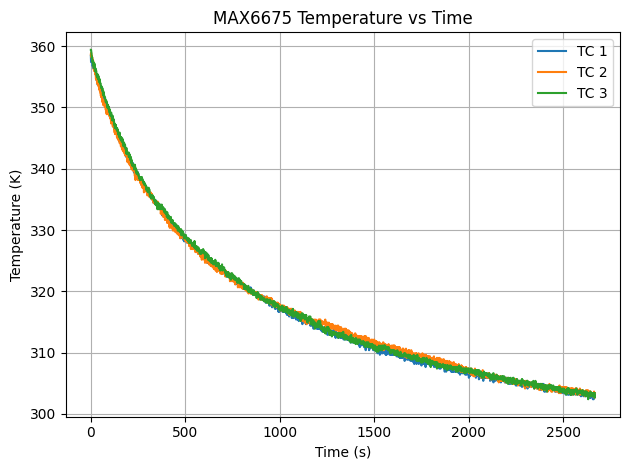

In [9]:
plot_max6675_datasets(test_data)

## 